# SEC Insider Transactions Data (2025)

This downloaded SEC Insider Transactions data sets for the year 2025 are stored in the `data` folder.
Data source: https://www.sec.gov/data-research/sec-markets-data/insider-transactions-data-sets

In [ ]:
import os
import requests
import zipfile
import io

# Ensure the data folder exists
data_dir = '../data/sec'
os.makedirs(data_dir, exist_ok=True)

# Set SEC-compliant User-Agent
# Note: The SEC requires the User-Agent to conform to the format:
# 'Sample Company Name AdminContact@<sample company domain>.com'
headers = {
    'User-Agent': 'info@example.com',
    'Accept-Encoding': 'gzip, deflate',
    'Host': 'www.sec.gov'
}

base_url = 'https://www.sec.gov/files/structureddata/data/insider-transactions-data-sets/'

# List of 2025 quarters
quarters = ['2025q1', '2025q2', '2025q3', '2025q4']

for quarter in quarters:
    filename = f"{quarter}_form345.zip"
    url = f"{base_url}{filename}"
    
    print(f"Fetching {filename}...")
    response = requests.get(url, headers=headers)
    
    if response.status_code == 200:
        # Save the zip file
        zip_path = os.path.join(data_dir, filename)
        with open(zip_path, 'wb') as f:
            f.write(response.content)
        print(f"Successfully downloaded {filename}")
        
        # Extract the zip file into its own quarter directory
        print(f"Extracting {filename} into {data_dir}/{quarter}...")
        extract_dir = os.path.join(data_dir, quarter)
        os.makedirs(extract_dir, exist_ok=True)
        
        try:
            with zipfile.ZipFile(io.BytesIO(response.content)) as z:
                z.extractall(extract_dir)
            print(f"Extraction complete for {quarter}.\n")
        except zipfile.BadZipFile:
            print(f"Downloaded file {filename} is not a valid zip file.\n")
            
    elif response.status_code == 404:
         print(f"File {filename} not found (Status code: 404). It may not be released yet.\n")
    elif response.status_code == 403:
         print(f"Access forbidden for {filename} (Status code: 403). Please verify your User-Agent.\n")
    else:
        print(f"Failed to download {filename} (Status code: {response.status_code})\n")

print("All requested downloads processed.")

Fetching 2025q1_form345.zip...


Successfully downloaded 2025q1_form345.zip
Extracting 2025q1_form345.zip into data/2025q1...


Extraction complete for 2025q1.

Fetching 2025q2_form345.zip...


Successfully downloaded 2025q2_form345.zip
Extracting 2025q2_form345.zip into data/2025q2...


Extraction complete for 2025q2.

Fetching 2025q3_form345.zip...


Successfully downloaded 2025q3_form345.zip
Extracting 2025q3_form345.zip into data/2025q3...
Extraction complete for 2025q3.

Fetching 2025q4_form345.zip...


Successfully downloaded 2025q4_form345.zip
Extracting 2025q4_form345.zip into data/2025q4...
Extraction complete for 2025q4.

All requested downloads processed.


In [2]:
import pandas as pd

# File paths for 2025 Q4 data
data_dir_q4 = '../data/sec/2025q4'

# 1. Load Submissions (contains Company Names and Tickers)
# low_memory=False used to handle mixed data types in TSV
sub_file = f'{data_dir_q4}/SUBMISSION.tsv'
df_sub = pd.read_csv(sub_file, sep='\t', low_memory=False)

print(f"Submissions shape: {df_sub.shape}")

df_sub

Submissions shape: (36421, 14)


,ACCESSION_NUMBER,FILING_DATE,PERIOD_OF_REPORT,DATE_OF_ORIG_SUB,NO_SECURITIES_OWNED,NOT_SUBJECT_SEC16,FORM3_HOLDINGS_REPORTED,FORM4_TRANS_REPORTED,DOCUMENT_TYPE,ISSUERCIK,ISSUERNAME,ISSUERTRADINGSYMBOL,REMARKS,AFF10B5ONE
0,0001819810-25-000241,31-OCT-2025,29-OCT-2025,NaN,NaN,0,NaN,NaN,4,1819810,Redwire Corp,RDW,NaN,0
1,0001225208-25-008847,31-OCT-2025,29-OCT-2025,NaN,NaN,NaN,NaN,NaN,4,898293,JABIL INC,JBL,NaN,0
2,0001437749-25-032579,31-OCT-2025,31-OCT-2025,NaN,NaN,1,NaN,NaN,4,1879103,"CFSB Bancorp, Inc. /MA/",CFSB,NaN,0
3,0001869216-25-000004,31-OCT-2025,29-OCT-2025,NaN,NaN,NaN,NaN,NaN,4,1699838,"Confluent, Inc.",CFLT,NaN,1
4,0001225208-25-008835,31-OCT-2025,29-OCT-2025,NaN,NaN,NaN,NaN,NaN,4,919012,AMERICAN EAGLE OUTFITTERS INC,AEO,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36416,0001193125-25-303338,01-DEC-2025,01-DEC-2025,NaN,NaN,true,NaN,NaN,4,1359841,Hanesbrands Inc.,HBI,NaN,false
36417,0001878313-25-000056,01-DEC-2025,26-NOV-2025,NaN,NaN,NaN,NaN,NaN,4,1878313,"MAIA Biotechnology, Inc.",MAIA,NaN,0
36418,0000935596-25-000028,01-DEC-2025,26-NOV-2025,NaN,NaN,0,NaN,NaN,4,800457,DONEGAL GROUP INC,DGICA,NaN,0
36419,0001878313-25-000052,01-DEC-2025,26-NOV-2025,NaN,NaN,NaN,NaN,NaN,4,1878313,"MAIA Biotechnology, Inc.",MAIA,NaN,0


In [4]:
# 2. Load Non-derivative Transactions (the actual trades)
trans_file = f'{data_dir_q4}/NONDERIV_TRANS.tsv'
df_trans = pd.read_csv(trans_file, sep='\t', low_memory=False)
print(f"Transactions shape: {df_trans.shape}")

df_trans

Transactions shape: (59678, 28)


,ACCESSION_NUMBER,NONDERIV_TRANS_SK,SECURITY_TITLE,SECURITY_TITLE_FN,TRANS_DATE,TRANS_DATE_FN,DEEMED_EXECUTION_DATE,DEEMED_EXECUTION_DATE_FN,TRANS_FORM_TYPE,TRANS_CODE,...,TRANS_ACQUIRED_DISP_CD,TRANS_ACQUIRED_DISP_CD_FN,SHRS_OWND_FOLWNG_TRANS,SHRS_OWND_FOLWNG_TRANS_FN,VALU_OWND_FOLWNG_TRANS,VALU_OWND_FOLWNG_TRANS_FN,DIRECT_INDIRECT_OWNERSHIP,DIRECT_INDIRECT_OWNERSHIP_FN,NATURE_OF_OWNERSHIP,NATURE_OF_OWNERSHIP_FN
0,0001104659-25-125707,8835098,Common Stock,NaN,29-DEC-2025,NaN,NaN,NaN,4.0,A,...,A,NaN,288032.00,NaN,NaN,NaN,D,NaN,NaN,NaN
1,0001104659-25-125707,8835099,Common Stock,NaN,31-DEC-2025,NaN,NaN,NaN,4.0,D,...,D,NaN,0.00,NaN,NaN,NaN,D,NaN,NaN,NaN
2,0001104659-25-125706,8835071,Common Stock,NaN,31-DEC-2025,NaN,NaN,NaN,4.0,D,...,D,NaN,0.00,NaN,NaN,NaN,D,NaN,NaN,NaN
3,0001104659-25-125706,8835070,Common Stock,NaN,29-DEC-2025,NaN,NaN,NaN,4.0,A,...,A,NaN,311110.00,NaN,NaN,NaN,D,NaN,NaN,NaN
4,0001104659-25-125705,8835003,Common Stock,NaN,29-DEC-2025,NaN,NaN,NaN,4.0,A,...,A,NaN,1506987.00,NaN,NaN,NaN,D,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59673,0001193125-25-225764,8774552,Common Stock,NaN,26-SEP-2025,NaN,NaN,NaN,4.0,A,...,A,NaN,9489.44,NaN,NaN,NaN,D,NaN,NaN,NaN
59674,0001193125-25-225764,8774553,Common Stock,NaN,26-SEP-2025,NaN,NaN,NaN,4.0,A,...,A,NaN,9489.57,NaN,NaN,NaN,D,NaN,NaN,NaN
59675,0001193125-25-225764,8774549,Common Stock,NaN,26-SEP-2025,NaN,NaN,NaN,4.0,A,...,A,NaN,9489.03,NaN,NaN,NaN,D,NaN,NaN,NaN
59676,0001193125-25-225764,8774548,Common Stock,NaN,26-SEP-2025,NaN,NaN,NaN,4.0,A,...,A,NaN,9481.32,NaN,NaN,NaN,D,NaN,NaN,NaN


In [2]:
# 3. Merge to link transactions with company details
df_merged = pd.merge(
    df_trans, 
    df_sub[['ACCESSION_NUMBER', 'ISSUERNAME', 'ISSUERTRADINGSYMBOL']], 
    on='ACCESSION_NUMBER', 
    how='inner'
)

df_merged



,ACCESSION_NUMBER,NONDERIV_TRANS_SK,SECURITY_TITLE,SECURITY_TITLE_FN,TRANS_DATE,TRANS_DATE_FN,DEEMED_EXECUTION_DATE,DEEMED_EXECUTION_DATE_FN,TRANS_FORM_TYPE,TRANS_CODE,...,SHRS_OWND_FOLWNG_TRANS,SHRS_OWND_FOLWNG_TRANS_FN,VALU_OWND_FOLWNG_TRANS,VALU_OWND_FOLWNG_TRANS_FN,DIRECT_INDIRECT_OWNERSHIP,DIRECT_INDIRECT_OWNERSHIP_FN,NATURE_OF_OWNERSHIP,NATURE_OF_OWNERSHIP_FN,ISSUERNAME,ISSUERTRADINGSYMBOL
0,0001104659-25-125707,8835098,Common Stock,NaN,29-DEC-2025,NaN,NaN,NaN,4.0,A,...,288032.00,NaN,NaN,NaN,D,NaN,NaN,NaN,"WideOpenWest, Inc.",WOW
1,0001104659-25-125707,8835099,Common Stock,NaN,31-DEC-2025,NaN,NaN,NaN,4.0,D,...,0.00,NaN,NaN,NaN,D,NaN,NaN,NaN,"WideOpenWest, Inc.",WOW
2,0001104659-25-125706,8835071,Common Stock,NaN,31-DEC-2025,NaN,NaN,NaN,4.0,D,...,0.00,NaN,NaN,NaN,D,NaN,NaN,NaN,"WideOpenWest, Inc.",WOW
3,0001104659-25-125706,8835070,Common Stock,NaN,29-DEC-2025,NaN,NaN,NaN,4.0,A,...,311110.00,NaN,NaN,NaN,D,NaN,NaN,NaN,"WideOpenWest, Inc.",WOW
4,0001104659-25-125705,8835003,Common Stock,NaN,29-DEC-2025,NaN,NaN,NaN,4.0,A,...,1506987.00,NaN,NaN,NaN,D,NaN,NaN,NaN,"WideOpenWest, Inc.",WOW
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59673,0001193125-25-225764,8774552,Common Stock,NaN,26-SEP-2025,NaN,NaN,NaN,4.0,A,...,9489.44,NaN,NaN,NaN,D,NaN,NaN,NaN,EnerSys,ENS
59674,0001193125-25-225764,8774553,Common Stock,NaN,26-SEP-2025,NaN,NaN,NaN,4.0,A,...,9489.57,NaN,NaN,NaN,D,NaN,NaN,NaN,EnerSys,ENS
59675,0001193125-25-225764,8774549,Common Stock,NaN,26-SEP-2025,NaN,NaN,NaN,4.0,A,...,9489.03,NaN,NaN,NaN,D,NaN,NaN,NaN,EnerSys,ENS
59676,0001193125-25-225764,8774548,Common Stock,NaN,26-SEP-2025,NaN,NaN,NaN,4.0,A,...,9481.32,NaN,NaN,NaN,D,NaN,NaN,NaN,EnerSys,ENS


In [5]:
# Convert shares and prices to numeric, handling any parsing errors
df_merged['TRANS_SHARES'] = pd.to_numeric(df_merged['TRANS_SHARES'], errors='coerce').fillna(0)
df_merged['TRANS_PRICEPERSHARE'] = pd.to_numeric(df_merged['TRANS_PRICEPERSHARE'], errors='coerce').fillna(0)

# 4. Filter for only basic Acquired (A) or Disposed (D) trades
df_ad = df_merged[df_merged['TRANS_ACQUIRED_DISP_CD'].isin(['A', 'D'])].copy()

df_ad


,ACCESSION_NUMBER,NONDERIV_TRANS_SK,SECURITY_TITLE,SECURITY_TITLE_FN,TRANS_DATE,TRANS_DATE_FN,DEEMED_EXECUTION_DATE,DEEMED_EXECUTION_DATE_FN,TRANS_FORM_TYPE,TRANS_CODE,...,SHRS_OWND_FOLWNG_TRANS,SHRS_OWND_FOLWNG_TRANS_FN,VALU_OWND_FOLWNG_TRANS,VALU_OWND_FOLWNG_TRANS_FN,DIRECT_INDIRECT_OWNERSHIP,DIRECT_INDIRECT_OWNERSHIP_FN,NATURE_OF_OWNERSHIP,NATURE_OF_OWNERSHIP_FN,ISSUERNAME,ISSUERTRADINGSYMBOL
0,0001104659-25-125707,8835098,Common Stock,NaN,29-DEC-2025,NaN,NaN,NaN,4.0,A,...,288032.00,NaN,NaN,NaN,D,NaN,NaN,NaN,"WideOpenWest, Inc.",WOW
1,0001104659-25-125707,8835099,Common Stock,NaN,31-DEC-2025,NaN,NaN,NaN,4.0,D,...,0.00,NaN,NaN,NaN,D,NaN,NaN,NaN,"WideOpenWest, Inc.",WOW
2,0001104659-25-125706,8835071,Common Stock,NaN,31-DEC-2025,NaN,NaN,NaN,4.0,D,...,0.00,NaN,NaN,NaN,D,NaN,NaN,NaN,"WideOpenWest, Inc.",WOW
3,0001104659-25-125706,8835070,Common Stock,NaN,29-DEC-2025,NaN,NaN,NaN,4.0,A,...,311110.00,NaN,NaN,NaN,D,NaN,NaN,NaN,"WideOpenWest, Inc.",WOW
4,0001104659-25-125705,8835003,Common Stock,NaN,29-DEC-2025,NaN,NaN,NaN,4.0,A,...,1506987.00,NaN,NaN,NaN,D,NaN,NaN,NaN,"WideOpenWest, Inc.",WOW
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59673,0001193125-25-225764,8774552,Common Stock,NaN,26-SEP-2025,NaN,NaN,NaN,4.0,A,...,9489.44,NaN,NaN,NaN,D,NaN,NaN,NaN,EnerSys,ENS
59674,0001193125-25-225764,8774553,Common Stock,NaN,26-SEP-2025,NaN,NaN,NaN,4.0,A,...,9489.57,NaN,NaN,NaN,D,NaN,NaN,NaN,EnerSys,ENS
59675,0001193125-25-225764,8774549,Common Stock,NaN,26-SEP-2025,NaN,NaN,NaN,4.0,A,...,9489.03,NaN,NaN,NaN,D,NaN,NaN,NaN,EnerSys,ENS
59676,0001193125-25-225764,8774548,Common Stock,NaN,26-SEP-2025,NaN,NaN,NaN,4.0,A,...,9481.32,NaN,NaN,NaN,D,NaN,NaN,NaN,EnerSys,ENS



--- Transaction Counts ---
TRANS_ACQUIRED_DISP_CD
D    34647
A    25031
Name: count, dtype: int64


/var/folders/qf/02fbzy5s2wx556kzmtxmskd40000gn/T/ipykernel_90694/523758.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_ad, x='TRANS_ACQUIRED_DISP_CD', palette='viridis')


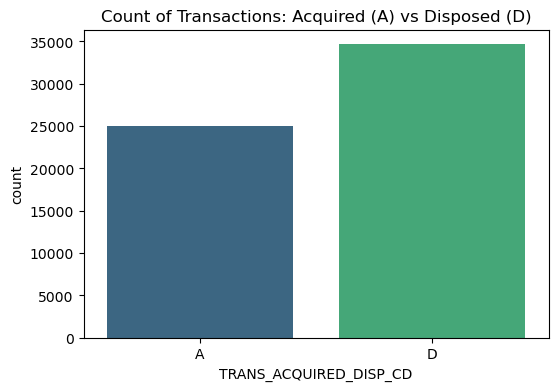


--- Top 10 Companies by Acquired (Buy) Value ---
ISSUERNAME
Kayne Anderson Energy Infrastructure Fund, Inc.        $325,000,000,711,150.00
Tesla, Inc.                                                $141,568,600,887.36
Summit Therapeutics Inc.                                       $546,499,852.88
Blackstone Private Real Estate Credit & Income Fund            $520,000,001.24
Medline Inc.                                                   $514,799,938.00
Immunovant, Inc.                                               $349,999,986.00
BGC Group, Inc.                                                $247,943,911.23
Merus N.V.                                                     $234,894,827.00
ICAHN ENTERPRISES L.P.                                         $234,600,481.50
LAS VEGAS SANDS CORP                                           $226,581,371.54
Name: A, dtype: object

--- Top 10 Companies by Disposed (Sell) Value ---
ISSUERNAME
ClearBridge Energy Midstream Opportunity Fund Inc.    $30,725,85

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 5. Plot the raw counts of Buys vs Sells
print("\n--- Transaction Counts ---")
print(df_ad['TRANS_ACQUIRED_DISP_CD'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(data=df_ad, x='TRANS_ACQUIRED_DISP_CD', palette='viridis')
plt.title('Count of Transactions: Acquired (A) vs Disposed (D)')
plt.show()

# 6. Calculate total monetary value of transactions
df_ad['TRANS_VALUE'] = df_ad['TRANS_SHARES'] * df_ad['TRANS_PRICEPERSHARE']

# Group by Issuer and Acquired/Disposed code to find the top companies
top_companies = df_ad.groupby(['ISSUERNAME', 'TRANS_ACQUIRED_DISP_CD'])['TRANS_VALUE'].sum().unstack(fill_value=0)

print("\n--- Top 10 Companies by Acquired (Buy) Value ---")
top_acquired = top_companies.sort_values(by='A', ascending=False).head(10)['A']
print(top_acquired.map('${:,.2f}'.format))

print("\n--- Top 10 Companies by Disposed (Sell) Value ---")
top_disposed = top_companies.sort_values(by='D', ascending=False).head(10)['D']
print(top_disposed.map('${:,.2f}'.format))
